In [1]:
import pandas as pd
import glob
import os

In [2]:
# folder = "./raw/California"

start = "202510"
end = "202605"

files = sorted([
    f for f in glob.glob(os.path.join("CRMLSSold*.csv"))
    if start <= os.path.basename(f).replace("CRMLSSold", "").replace(".csv", "") <= end
])

dfs = []

for file in files:
    df = pd.read_csv(file)

    filename = os.path.basename(file)
    yyyymm = filename.replace("CRMLSSold", "").replace(".csv", "")

    df["date"] = pd.to_datetime(yyyymm, format="%Y%m")

    dfs.append(df)

sold_df = pd.concat(dfs, ignore_index=True)

print(sold_df.shape)
sold_df.head()

/var/folders/yg/htr3vlg56hvfr0cd4v_9cfnc0000gn/T/ipykernel_45173/2973829602.py:14: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


(166725, 79)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,date
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,1807.0,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN,2025-10-01
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,14253.0,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN,2025-10-01
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN,2025-10-01
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN,2025-10-01
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN,2025-10-01


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data
df_filtered = sold_df[
    (sold_df["PropertyType"] == "Residential") &
    (sold_df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Rows after filtering: {df_filtered.shape[0]}")

# Target variables
features = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeArea"]

# Descriptive statistics
print(df_filtered[features].describe())


Rows after filtering: 83495
         ClosePrice    LivingArea  BedroomsTotal  BathroomsTotalInteger  \
count  8.349500e+04  83456.000000   83495.000000           83494.000000   
mean   1.339031e+06   2053.871883       3.497311               2.640549   
std    7.664041e+06   1037.807531       0.966113               1.131176   
min    1.750000e+00      0.000000       0.000000               0.000000   
25%    6.200000e+05   1388.000000       3.000000               2.000000   
50%    8.890000e+05   1824.000000       3.000000               2.000000   
75%    1.415000e+06   2450.000000       4.000000               3.000000   
max    9.895000e+08  31068.000000      22.000000              23.000000   

        LotSizeArea  
count  8.205900e+04  
mean   1.851676e+04  
std    1.809819e+05  
min    0.000000e+00  
25%    5.388000e+03  
50%    7.029000e+03  
75%    9.887500e+03  
max    3.164242e+07  


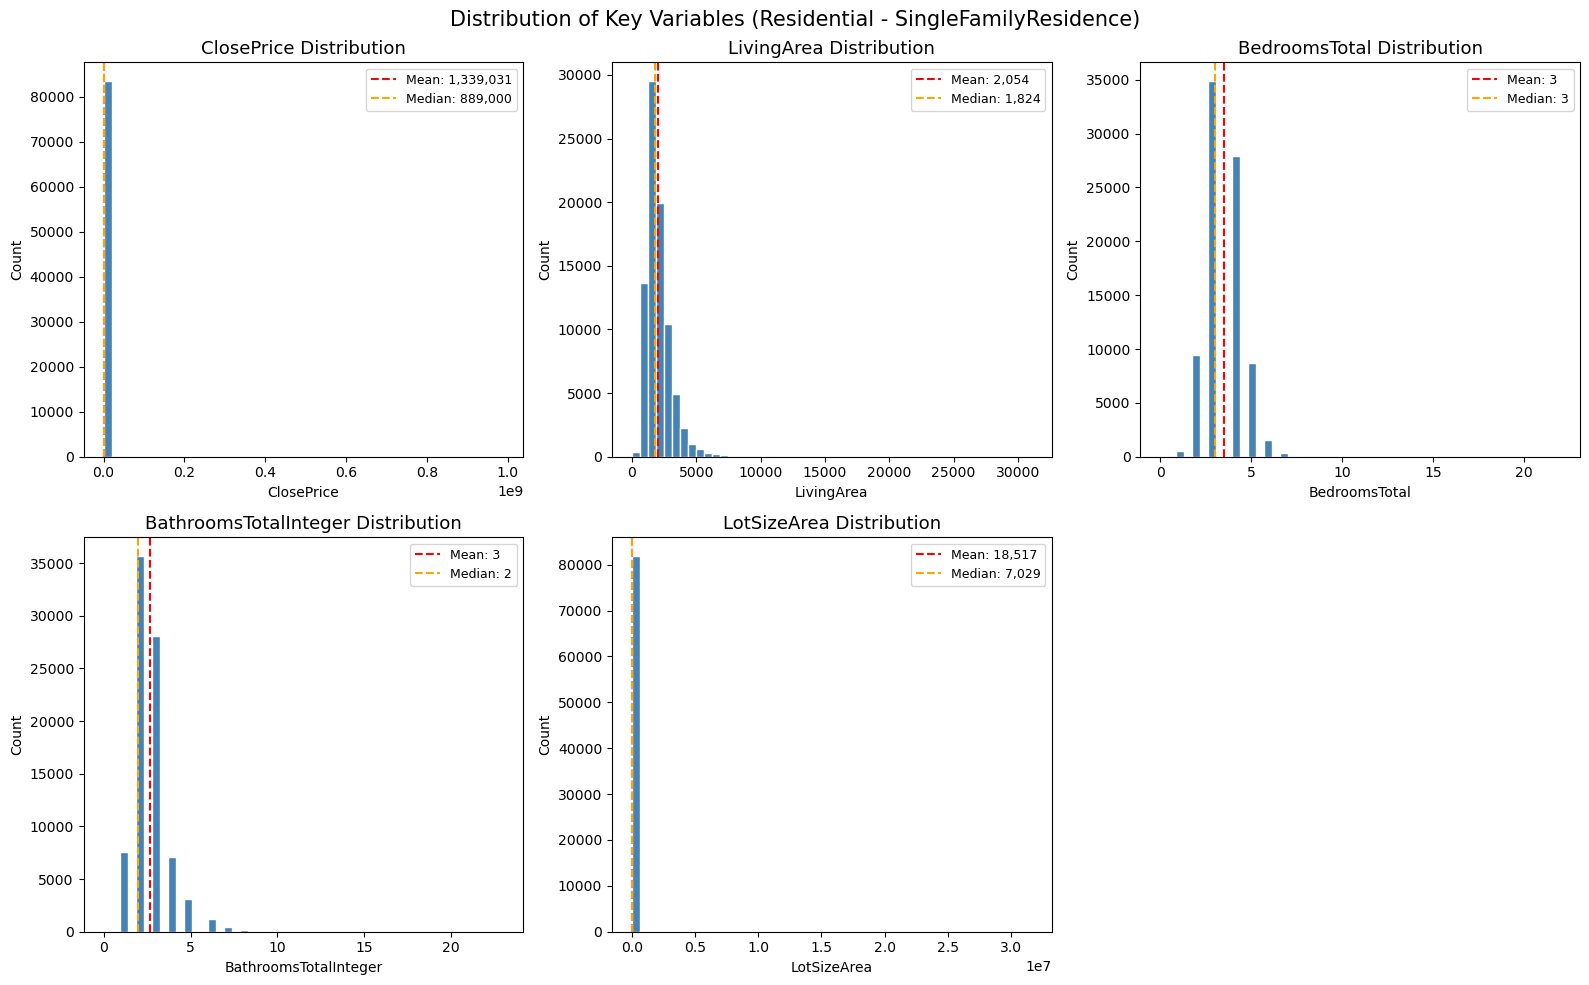

In [4]:

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df_filtered[col].dropna()
    
    axes[i].hist(data, bins=50, edgecolor='white', color='steelblue')
    axes[i].set_title(f"{col} Distribution", fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    
    # Mean / Median lines
    axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():,.0f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', label=f'Median: {data.median():,.0f}')
    axes[i].legend(fontsize=9)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Distribution of Key Variables (Residential - SingleFamilyResidence)", fontsize=15)
plt.tight_layout()
plt.show()


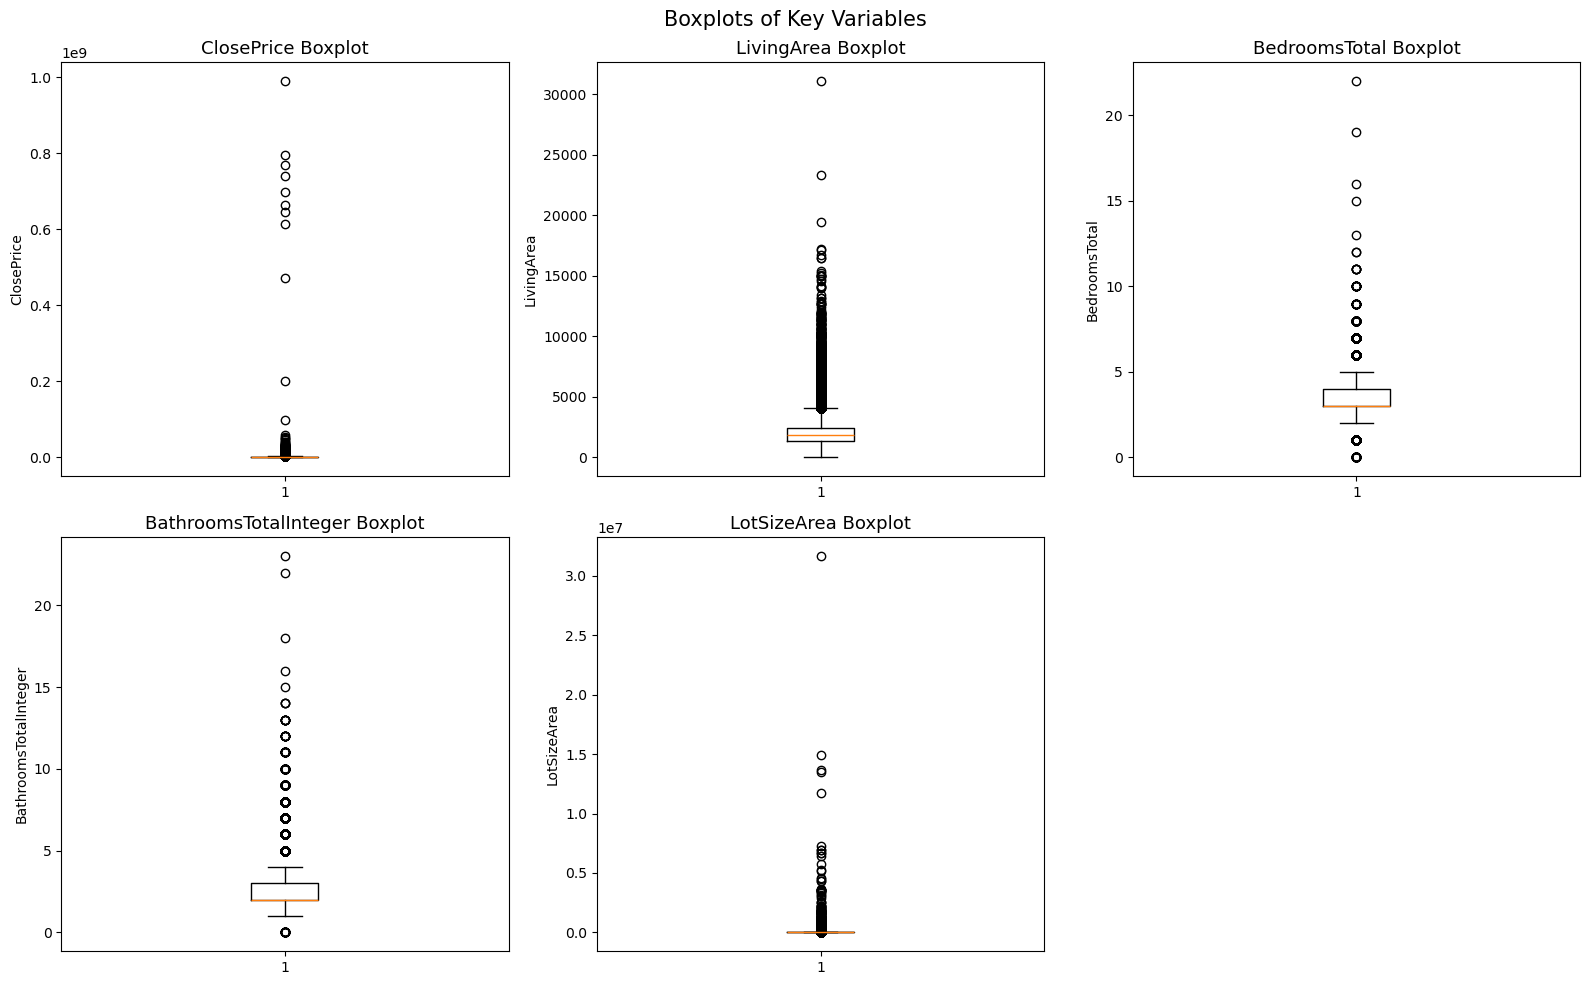

In [5]:

# Boxplots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df_filtered[col].dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(f"{col} Boxplot", fontsize=13)
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)

plt.suptitle("Boxplots of Key Variables", fontsize=15)
plt.tight_layout()
plt.show()

In [7]:
df_filtered.to_csv("merged_sales_data.csv", index=False)